# Intelligent Login Risk Analyzer  
## Notebook 02: Dataset Exploration

This notebook explores the login dataset to understand patterns, distributions, and user behavior before building anomaly detection logic.

## Step 1: Import Required Libraries

We import necessary libraries for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Dataset

We load the login dataset from the data folder.

In [2]:
df = pd.read_excel('../data/dummy_login_dataset_300_rows.xlsx')
df.head()

,user,time,ip,location,device,status
0,user15,23:27,111.63.15.123,India,Edge,failed
1,user6,04:44,160.179.176.83,Rajshahi,Chrome,failed
2,user1,04:27,22.83.109.113,Sylhet,Firefox,failed
3,user14,17:16,15.4.242.67,Khulna,Chrome,success
4,user9,08:56,216.156.140.216,USA,Mobile,failed


## Step 3: Analyze Login Status Distribution

In this step, we analyze the distribution of login outcomes (successful vs failed attempts).

Understanding this distribution is important for:
- identifying unusual login patterns  
- detecting potential brute-force or suspicious login behavior  
- forming the basis for anomaly detection in later stages  

We will first count the occurrences and then visualize them.

In [3]:
df['status'].value_counts()

status
failed     163
success    137
Name: count, dtype: int64

### Visualization: Login Status Distribution

We visualize the login status distribution using a bar chart for better understanding of the data balance.

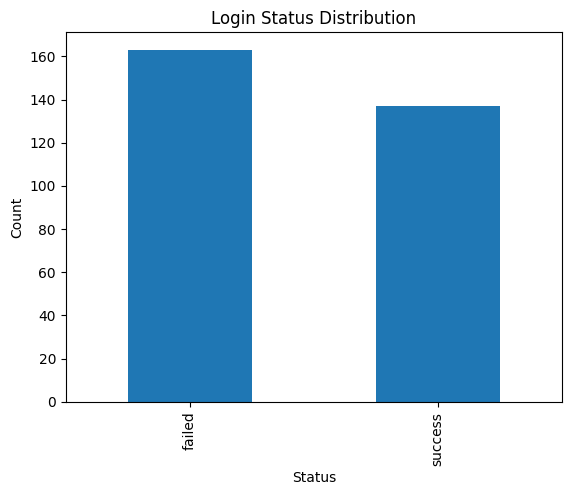

In [4]:
df['status'].value_counts().plot(kind='bar')
plt.title('Login Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

## Step 4: Identify Users with Most Failed Login Attempts

In this step, we identify users who have the highest number of failed login attempts.

This is crucial for detecting:
- potential brute-force attacks  
- compromised accounts  
- suspicious user behavior  

In [5]:
failed_logins = df[df['status'] == 'failed']
failed_logins['user'].value_counts()

user
user16    14
user2     14
user15    11
user4     11
user11    11
user17     9
user5      9
user9      8
user20     8
user14     8
user13     8
user19     8
user6      7
user1      7
user18     6
user12     6
user10     5
user8      5
user3      5
user7      3
Name: count, dtype: int64

## Step 5: Analyze Failed Logins by Location

In this step, we analyze the geographic distribution of failed login attempts.

This helps identify:
- suspicious login attempts from unusual locations  
- potential attack sources  
- abnormal geographic patterns  

Location-based anomalies are a key component in real-world security systems.

In [6]:
failed_logins['location'].value_counts()

location
India         24
Sylhet        21
Khulna        20
USA           19
Dhaka         19
Chittagong    17
Russia        16
UK            14
Rajshahi      13
Name: count, dtype: int64

### Visualization: Failed Logins by Location

We visualize the number of failed login attempts per location to detect high-risk regions.

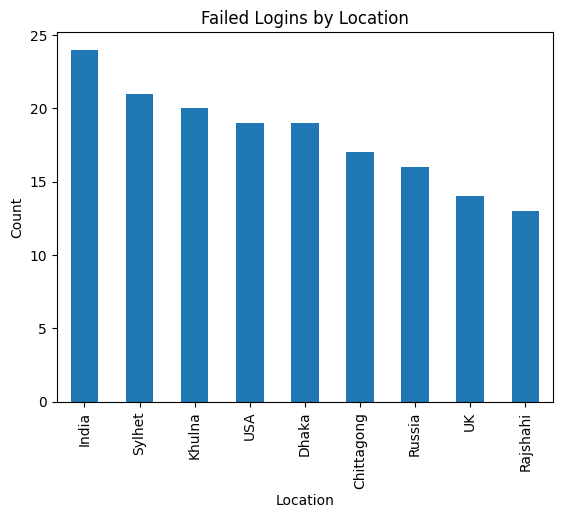

In [7]:
failed_logins['location'].value_counts().plot(kind='bar')
plt.title('Failed Logins by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

## Step 6: Analyze Failed Logins by Device

In this step, we analyze login failures based on device type.

This helps identify:
- suspicious login attempts from specific devices  
- automated attack patterns (e.g., bots using certain browsers)  
- unusual device behavior  

Device-level analysis is widely used in fraud detection systems.

In [10]:
df.rename(columns={'device': 'device_or_browser'}, inplace=True)

failed_logins = df[df['status'] == 'failed']

failed_logins['device_or_browser'].value_counts()

device_or_browser
Mobile     58
Chrome     39
Edge       33
Firefox    33
Name: count, dtype: int64

## Step 7: Analyze Login Activity by Time

In this step, we analyze login activity based on time of day.

This helps identify:
- unusual login hours (e.g., late night or early morning)
- potential suspicious behavior patterns  
- anomalies in user activity timing  

Time-based analysis is widely used in fraud detection and cybersecurity systems.

In [11]:
#Convert time column
df['time'] = pd.to_datetime(df['time'], format='%H:%M')

In [12]:
#Extract hour
df['hour'] = df['time'].dt.hour

In [13]:
#Analyze distribution
df['hour'].value_counts().sort_index()

hour
0     20
1     16
2     14
3     13
4     12
5     13
6     13
7     15
8     11
9     13
10     8
11    10
12     6
13    11
14    13
15    18
16    18
17    17
18    12
19     9
20     9
21    19
22     5
23     5
Name: count, dtype: int64

### Visualization: Login Activity by Hour

We visualize login attempts across different hours of the day to detect unusual activity patterns.

### Key Insight

We observe login activity during late-night hours (e.g., 0–5 AM).

In real-world systems, such activity can indicate:
- automated attack attempts  
- compromised accounts  
- abnormal user behavior  

This pattern may require further investigation or risk scoring.

### Visualization: Login Activity by Hour

We visualize login activity across different hours to better understand time-based patterns.

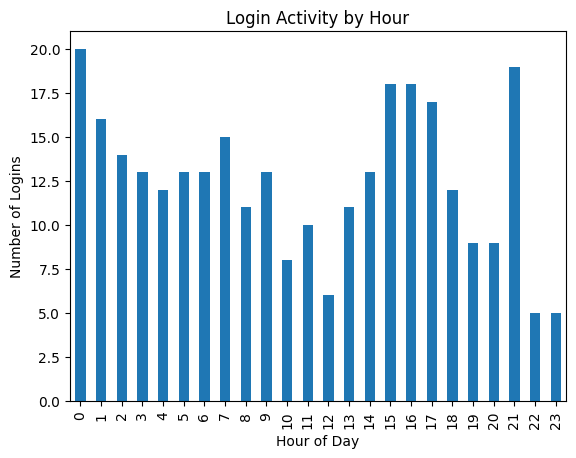

In [14]:
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Login Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Logins')
plt.show()

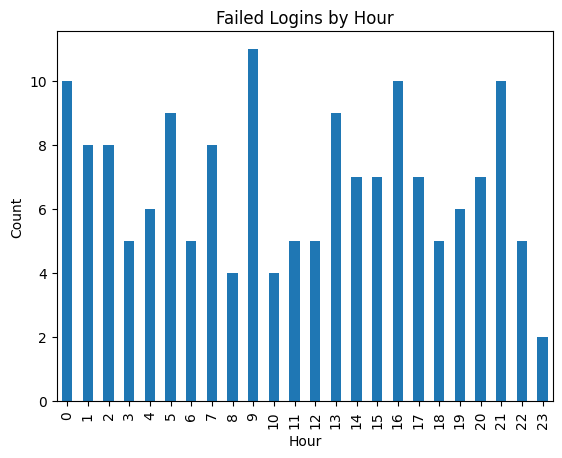

In [15]:
failed_logins = df[df['status'] == 'failed']

failed_logins['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Failed Logins by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

### Key Observation

Failed login attempts are distributed across different hours.

If higher failures occur during unusual hours, it may indicate:
- brute-force attacks  
- automated login attempts  
- suspicious activity patterns  

## Step 8: Feature Engineering

In this step, we transform raw data into meaningful features for machine learning.

Feature engineering helps:
- convert categorical data into numerical form  
- highlight suspicious patterns  
- prepare the dataset for anomaly detection models  

In [16]:
# Convert login status to numeric (1 = failed, 0 = success)
df['is_failed'] = df['status'].apply(lambda x: 1 if x == 'failed' else 0)

# Identify night logins (0–5 AM considered suspicious)
df['is_night_login'] = df['hour'].apply(lambda x: 1 if 0 <= x <= 5 else 0)

# Flag high-risk locations
high_risk_locations = ['Russia']
df['is_high_risk_location'] = df['location'].apply(
    lambda x: 1 if x in high_risk_locations else 0
)

# Flag suspicious device usage (e.g., mobile)
df['is_suspicious_device'] = df['device_or_browser'].apply(
    lambda x: 1 if x == 'Mobile' else 0
)

## Step 9: Risk Scoring System

In this step, we assign a risk score to each login attempt based on suspicious behavior patterns such as:

- Failed login attempts
- Night-time activity
- High-risk locations
- Suspicious device usage

This score helps prioritize potentially dangerous login attempts for further investigation.

In [17]:
# Assign weights to each risk factor
df['risk_score'] = (
    df['is_failed'] * 3 +            # Failed login → high importance
    df['is_night_login'] * 2 +       # Night login → medium risk
    df['is_high_risk_location'] * 3 +# Risky location → high importance
    df['is_suspicious_device'] * 1   # Device risk → lower importance
)

# View top risky logins
df.sort_values(by='risk_score', ascending=False).head(10)

,user,time,ip,location,device_or_browser,status,hour,is_failed,is_night_login,is_high_risk_location,is_suspicious_device,risk_score
147,user13,1900-01-01 01:53:00,77.40.216.122,Russia,Mobile,failed,1,1,1,1,1,9
244,user4,1900-01-01 09:19:00,255.52.105.179,Russia,Mobile,failed,9,1,0,1,1,7
141,user2,1900-01-01 09:32:00,101.166.243.239,Russia,Mobile,failed,9,1,0,1,1,7
50,user11,1900-01-01 18:37:00,125.68.70.211,Russia,Mobile,failed,18,1,0,1,1,7
142,user5,1900-01-01 11:58:00,148.90.233.222,Russia,Mobile,failed,11,1,0,1,1,7
196,user7,1900-01-01 13:41:00,127.11.20.126,Russia,Mobile,failed,13,1,0,1,1,7
270,user14,1900-01-01 02:57:00,255.150.148.85,Dhaka,Mobile,failed,2,1,1,0,1,6
151,user1,1900-01-01 04:34:00,33.77.7.252,Sylhet,Mobile,failed,4,1,1,0,1,6
269,user11,1900-01-01 16:47:00,209.5.240.232,Russia,Edge,failed,16,1,0,1,0,6
27,user4,1900-01-01 16:08:00,137.101.102.134,Russia,Firefox,failed,16,1,0,1,0,6


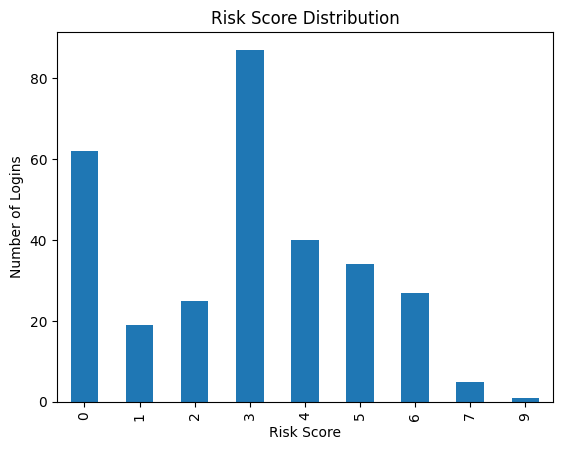

In [18]:
# Plot risk score distribution
df['risk_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Number of Logins')
plt.show()

## Step 10: Flag High-Risk Logins

In this step, we classify login attempts based on their risk score.

This helps:
- identify the most suspicious login attempts
- create a simple alerting mechanism
- support security monitoring and investigation

In [19]:
# Classify login attempts based on risk score
def classify_risk(score):
    if score >= 6:
        return 'High'
    elif score >= 3:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df['risk_score'].apply(classify_risk)

# View risk classification counts
df['risk_level'].value_counts()

risk_level
Medium    161
Low       106
High       33
Name: count, dtype: int64

### Visualization: Risk Level Distribution

We visualize how many login attempts fall into Low, Medium, and High risk categories.

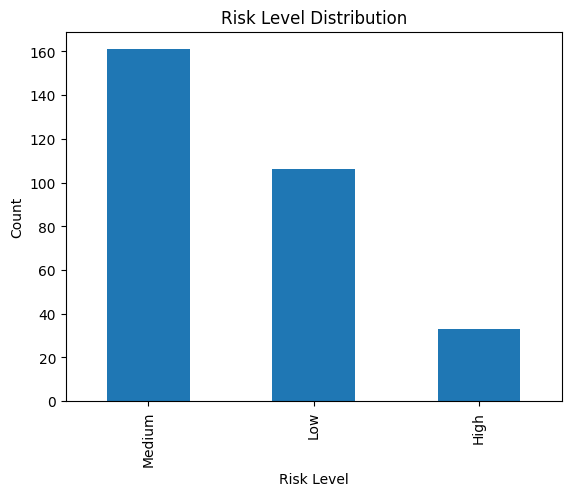

In [20]:
df['risk_level'].value_counts().plot(kind='bar')
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

## Step 11: Inspect High-Risk Login Attempts

In this step, we filter the dataset to review login attempts classified as High risk.

This helps us understand which combinations of features are producing strong alerts.

In [21]:
high_risk_logins = df[df['risk_level'] == 'High']

high_risk_logins[['user', 'time', 'location', 'device_or_browser', 'status', 'hour', 'risk_score', 'risk_level']].head(10)

,user,time,location,device_or_browser,status,hour,risk_score,risk_level
13,user16,1900-01-01 21:15:00,Russia,Chrome,failed,21,6,High
14,user17,1900-01-01 03:46:00,Sylhet,Mobile,failed,3,6,High
27,user4,1900-01-01 16:08:00,Russia,Firefox,failed,16,6,High
32,user4,1900-01-01 00:19:00,Khulna,Mobile,failed,0,6,High
50,user11,1900-01-01 18:37:00,Russia,Mobile,failed,18,7,High
52,user17,1900-01-01 09:05:00,Russia,Edge,failed,9,6,High
59,user3,1900-01-01 00:27:00,USA,Mobile,failed,0,6,High
65,user2,1900-01-01 03:03:00,USA,Mobile,failed,3,6,High
83,user1,1900-01-01 03:56:00,Dhaka,Mobile,failed,3,6,High
104,user12,1900-01-01 16:50:00,Russia,Edge,failed,16,6,High


## Step 12: Key Insight

At this stage, the system can already:
- identify suspicious login attempts
- assign a numerical risk score
- classify login events into risk categories
- support future anomaly detection and alerting workflows

This forms the foundation for a practical login anomaly detection system.

## Final Summary of Notebook 02

In this notebook, we explored the login dataset from a cybersecurity perspective and identified important risk patterns.

Main findings:
- failed login attempts are common and useful for security analysis
- some users show higher failed login frequency than others
- certain locations contribute more failed logins
- browser/device patterns may help identify suspicious activity
- login activity during unusual hours can indicate abnormal behavior
- engineered features such as failed status, night login, and high-risk location help convert raw data into model-ready inputs
- a simple risk scoring system can already classify suspicious login attempts into low, medium, and high risk

This notebook establishes the analytical foundation for the next stage: feature engineering and anomaly detection modeling.